# Organelle Scanning & Mask Refinement
This notebook detects mitochondria and nucleus in tomograms, post-processes slice-wise detections into candidates, visualizes query boxes, and generates refined masks with class-specific parameters.

## Release Notes
- Expected input: a single `.mrc` tomogram path in the dataset cell.
- Default classes: `mitochondria`, `nucleus`, and background `None`.
- Run cells top-to-bottom; adjust DBSCAN and mask thresholds per dataset.
- Outputs are in-memory DataFrames/masks for inspection and downstream export.

## Environment and Imports
Load required Python packages and project modules.
Run this section once after starting a fresh kernel.

In [46]:
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

sys.path.append("../src")

import data
import modules
import postprocess
import utils

importlib.reload(postprocess)

<module 'postprocess' from '/home/feity/cryoem/notebooks/../src/postprocess.py'>

## Load Trained Detector
Load the pretrained organelle model checkpoint and switch to evaluation mode.
This model is used for slice-wise candidate generation.

In [47]:
model = utils.loadModel("<pathto>/release_model/mitochondria&nucleus", "last.ckpt")
model = model.eval()  

model at stage  stage 1
model with output classes 3
model receiving class weights tensor([1.0000, 1.0000, 0.2000])
using consistency regularization coef 0.5


/data/biosoftware/miniconda3/miniconda3/envs/tomognn/lib/python3.11/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
/home/feity/cryoem/notebooks/../src/utils.py:1397: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will

incompatible parameters []
finish loading parameters


## Build Inference Dataset and Generate Candidates
Create a `TestDatasetMrc` object from the input tomogram and run candidate generation.
Embeddings from this step are reused later for mask-stage inference.

In [ ]:
# Move model to GPU when available for faster inference.
if torch.cuda.is_available():
    model = model.cuda(0)

dataset = data.TestDatasetMrc(
    "<pathto>/release_model/data_example/mitochondria_nucleus.mrc",
    norm="hist",
    reshape=800,
    gap=5,
    length_for_average=3,
 )

# `generatedf` is recommended for larger organelles when larger `gap` is used.
# Full-graph generation on dense sampling can trigger OOM on limited GPUs.
df, embeds = postprocess.generatedf(
    model,
    dataset,
    gap=5,
    columns=["mitochondria", "nucleus", "None"],
    return_embeds=True,
 )
all_x = np.concatenate(embeds, axis=0)

# For smaller gap values, `generatedfBySlice` can be more memory efficient.
# It trades long-range 3D connectivity for lower memory usage.
# df, returns = postprocess.generatedfBySlice(model, dataset, gap=5, columns=["mitochondria", "nucleus", "None"], return_retdict=True)
# all_x = [returns[i]["feature"][0] for i in range(np.min(list(returns.keys())), np.max(list(returns.keys())) + 1)]
# all_x = torch.cat(all_x, dim=0)

loading test dataset


100%|██████████| 100/100 [00:17<00:00,  5.80it/s]


finish dataset


100%|██████████| 100/100 [00:18<00:00,  5.43it/s]


finish dataset


...

finish dataset


100%|██████████| 100/100 [00:17<00:00,  5.78it/s]


finish dataset


100%|██████████| 100/100 [00:17<00:00,  5.66it/s]


finish dataset


## Clustering and Filtering
Apply DBSCAN-based grouping and class-specific filtering to reduce false positives.
Tune thresholds in `params` and `mark_and_filter` for each tomogram/domain.

In [49]:
# DBSCAN clustering is optional for organelle workflows.
# It helps create instance-level IDs and suppress obvious false positives.
df["unlabeled"] = True
df["label"] = ""
df["label_id"] = -1

# Tune these per tomogram because score distributions vary by acquisition/contrast.
params = {
    "mitochondria": {"min_prob": 0.5, "nms": 0.2, "cluster_params": {"min_samples": 11, "eps": 0.5, "dis_penalty_cutoff": 10}},
    "nucleus": {"min_prob": 0.25, "nms": 0.2, "cluster_params": {"min_samples": 11, "eps": 0.5, "dis_penalty_cutoff": 10}},
}
mark_and_filter = {
    "nucleus": {"max_cnt": 1, "remove_iou": 0.4, "min_samples": 20, "extend": 40},
    "mitochondria": {"max_cnt": 10, "remove_iou": 0.6, "min_samples": 20},
}

for i in ["nucleus", "mitochondria"]:
    subdf = postprocess.processClass(df, i, **params[i], method="DBSCAN")
    postprocess.markFilter(df, i, subdf, **mark_and_filter[i])

df.head()

11 0.5 0.02 10
number of instances in class  2
11 0.5 0.02 10
number of instances in class  5


,z,x,y,w,h,mitochondria,nucleus,None,max,largest,unlabeled,label,label_id,class_value
0,0,0.018113,0.530231,0.039527,0.062366,0.455248,0.006823,0.537929,0.537929,None,True,,-1,0.455248
1,0,0.224946,0.974976,0.075864,0.049954,0.323296,0.074893,0.601811,0.601811,None,True,,-1,0.323296
2,0,0.204627,0.505776,0.421063,0.978852,0.243659,0.287612,0.468729,0.468729,None,False,nucleus,0,0.243659
3,5,0.163941,0.963985,0.162177,0.071033,0.289979,0.138957,0.571064,0.571064,None,True,,-1,0.289979
4,5,0.225365,0.506887,0.450261,0.981299,0.254245,0.290171,0.455584,0.455584,None,False,nucleus,0,0.254245


## Select Candidate Queries for Masking
Choose slice-level candidates (automatically or manually) that will be used as mask prompts.
This step also visualizes selected bounding boxes for quick quality control.

/tmp/ipykernel_23413/1629361451.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes) * torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/notebooks/../src/utils.py:71: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)


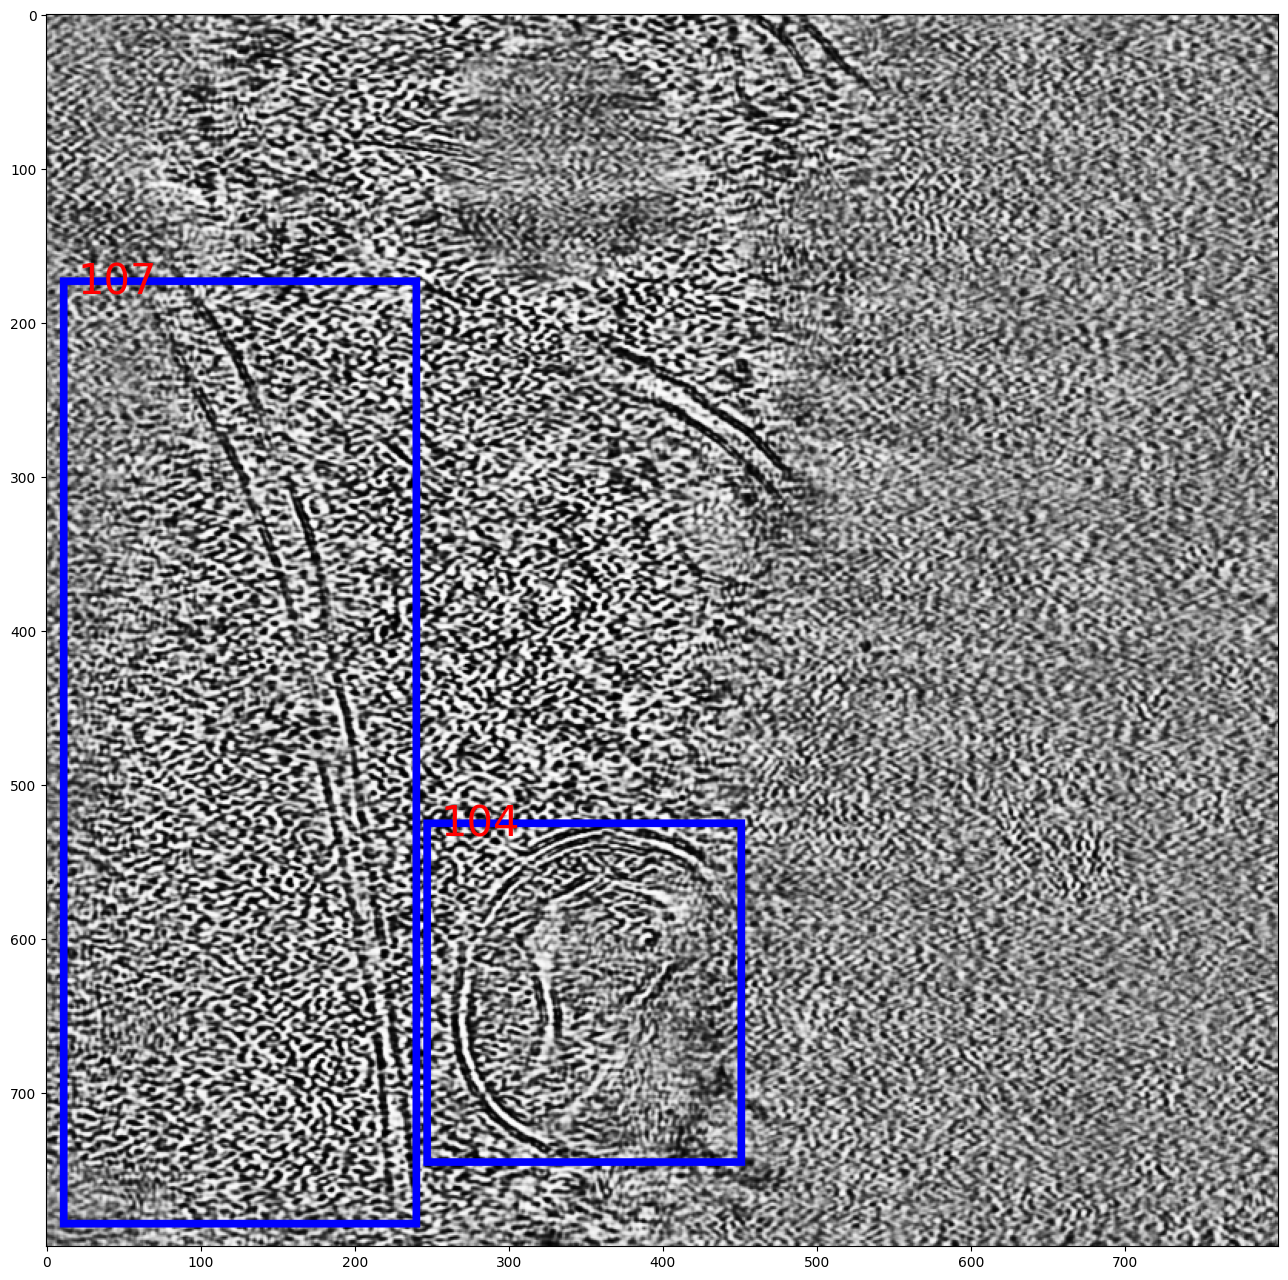

In [50]:
take = 180

subdf = df
subdf = subdf[subdf["z"] == take]
# Select candidate queries for mask inference.
# DBSCAN labels help narrow down likely true objects.

subdf = subdf[(subdf["label"] != "")]

# Optional manual filtering examples:
# subdf = subdf[subdf["nucleus"] > 0.15]
# subdf = subdf[subdf["None"] < 0.8]

# Optional manual selection when ranking is imperfect.
# subdf = subdf.loc[[107, 104]]

img = dataset.__getitem__(pos=take)["pixel_values"]

bboxes = subdf[["x", "y", "w", "h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes) * torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])

# Render grayscale tomogram in RGB channels for annotation utility.
img[0] = img[1]
img[2] = img[1]

names = list(subdf.index)
labels = {"bboxes": bboxes, "labels": names}

plt.figure(figsize=(16, 16))
utils.drawannotation(img, labels, font_size=30)
plt.show()
plt.close()

## Configure Mask Refinement Parameters
Set class-specific mask thresholding and morphological refinement hyperparameters.
Adjust these values based on object size, contrast, and boundary smoothness.

In [51]:
refine_mask = {
    "nucleus":{"smooth": 4.0, "morph_open_kernal_size":(7, 7), "morph_close_kernal_size": (7, 7), "blur_ksize": (25, 25), "max_contours": 1, "apply_convex_hull":False}, 
    "mitochondria":{"smooth": 4.0, "morph_open_kernal_size":(5, 5), "morph_close_kernal_size": (5, 5), "blur_ksize": (15, 15), "max_contours": 1, "apply_convex_hull":False},  
}
mask_thres = {  
    "mitochondria":0.6,
    "nucleus":0.75,    
}

## Mask-Stage Inference and Refinement
Run the mask head for each selected query, then refine raw masks with class-specific post-processing.
Outputs are stored in `original_masks` and `masks` for downstream analysis/export.

In [52]:
model.stage = "stage mask"
# During mask training, box prompts are only provided part of the time;
# here we force prompt usage during inference for stable outputs.
model.mask_head.TF = 1.0

masks = []
original_masks = []
for i, r in subdf.iterrows():
    # `all_x[i]` stores candidate metadata + embedding; last 256 dims are features.
    x = torch.tensor(all_x[i][-256:]).unsqueeze(0).to(model.device)
    boxes = torch.tensor(r[["x", "y", "w", "h"]].values.astype(np.float32)).unsqueeze(0).to(model.device)
    data = dataset.__getitem__(pos=int(all_x[i][0] * 500))
    pv = data["pixel_values"].unsqueeze(0).float().to(model.device)

    with torch.no_grad():
        out = model(pixel_values=pv, embed=x, box=boxes)
        out = torch.sigmoid(out).detach().cpu().numpy()

    original_masks.append(out.squeeze())
    refined_mask = postprocess.refineMask(
        out.squeeze(),
        thres=mask_thres[r["label"]],
        **refine_mask[r["label"]],
    )
    masks.append(refined_mask)

## Visualize Example Mask Output
Display representative raw mask predictions for quick visual inspection.
Use this section to sanity-check threshold and refinement settings.

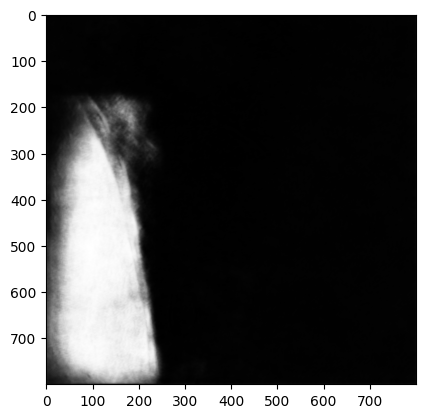

In [53]:
plt.imshow(original_masks[1], cmap="gray")

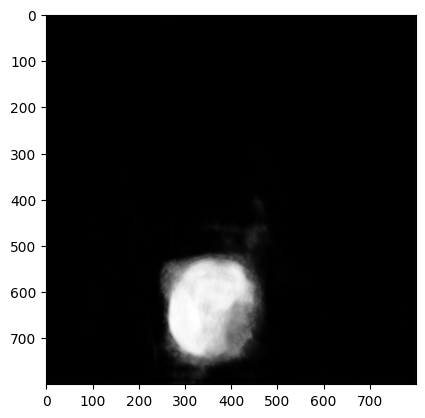

In [54]:
plt.imshow(original_masks[0], cmap="gray")